
# Lab 3: PDE with FDM

In [1]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import sympy as sp

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.

time(s)= 1.15625
error=0.0009998893285754207


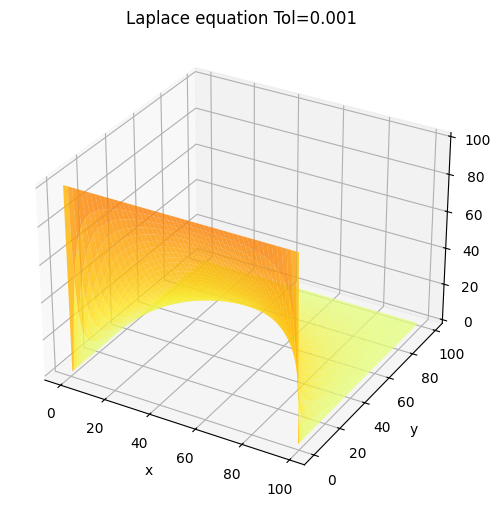

In [2]:
def Laplace2D_FDM(V_ini,tol):
  
  V = V_ini.copy()
  error = 1.0
  iters = 0
  
  while error > tol:
    V_old = V.copy()
    
    V[1:-1,1:-1]=0.25*(V_old[2:, 1:-1]+V_old[:-2, 1:-1]+V_old[1:-1, 2:]+V_old[1:-1, :-2])
    
    error=np.max(np.abs(V-V_old))
    iters+=1
    
  return V,iters,error

def grid(V_ini, x, y):
    X, Y = np.meshgrid(x, y) 
    Z = V_ini.T
    return X, Y, Z

# Confiuración de voltaje inicial en la malla
Nmax= 100
tol=1e-3
V_ini = np.zeros((Nmax, Nmax), float)

for k in range(0, Nmax):
  V_ini[k,0] = 100. # "Llenado' de voltaje punto a punto por todo el eje inferior

x = np.arange(0, Nmax, 1)
y = np.arange(0, Nmax, 1)

start = tm.process_time()
V,iters,error = Laplace2D_FDM(V_ini,tol)
X,Y,Z = grid(V,x,y)
end = tm.process_time()
print(f'time(s)= {end-start}\nerror={error}')

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='Wistia', alpha=0.8)
ax.set_title(f'Laplace equation Tol={tol}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

El método usado para comparar y dar con un error deseado fue no usar ciclos for para iterar sobre cada índice $i,j$ y calcular la solución independientemente para cada punto y luego calcular el error; este método sería muy engorroso ya que calcula punto por punto y se demora mucho más.

```python
for iter in range(Niter): 
    for i in range(1, Nmax-1):
        for j in range(1, Nmax-1):
            V[i,j] = 0.25*(V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
    error=np.max(np.abs(V-V_old))
```

En lugar de esto, se aprovecha el potencial matricial de Numpy calculando el siguiente estado de tal manera que el nodo en la siguiente "foto" sea el promedio de los cuatro vecinos. Esto se consigue sumando 4 matrices desplazadas con respecto a una original, primero se escoge la matriz original pero sin los bordes ya que están con las condiciones iniciales, luego a esa matriz se le suman las cuatro mismas matrices pero desplazadas hacia arriba, abajo, izquierda y derecha. Al hacer las operaciones de esta manera ahorra tiempo de cómputo al no hacer cálculos uno a uno, sino matricialmente con esta rutina:


```python
V[1:-1,1:-1]=0.25*(V_old[2:, 1:-1]+V_old[:-2, 1:-1]+V_old[1:-1, 2:]+V_old[1:-1, :-2])
```

2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

In [5]:
def un(x, y, n=1, L=1):
    '''function to compute the n-esimo term of the Fouriers serie'''
    v0 = 100
    return (4*v0/(n*np.pi)) * np.sin(n*np.pi*x/L) * np.sinh(n*np.pi*(L-y)/L) / np.sinh(n*np.pi)

L = 1 
coordx = np.linspace(0, L, 100)
coordy = coordx
x, y = np.meshgrid(coordx, coordy, indexing='ij')

tol = 1e-4
z = np.zeros_like(x)
n = 1
terminos = 0
error = 1.0

start = tm.process_time()

while error > tol:
    term = un(x, y, n, L)
    z += term
    terminos += 1
    error = np.max(np.abs(term[:, 1:]))
    n += 2

print(f'Iteraciones para tol={tol}: {n}')

end = tm.process_time()
print(f'time(s)= {end-start}')

Iteraciones para tol=0.0001: 101
time(s)= 0.0625


#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

### 1. Separación de Variables
El primer paso asume que la solución $u(x,y)$ se puede expresar como el producto de dos funciones independientes, una que depende solo de $x$ y otra solo de $y$:
$$u(x,y) = X(x)Y(y)$$

Sustituimos esto en la ecuación de Laplace ($\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$):
$$X''(x)Y(y) + X(x)Y''(y) = 0$$

Dividimos toda la ecuación por $X(x)Y(y)$ para separar las variables a cada lado de la igualdad. Como un lado depende solo de $x$ y el otro solo de $y$, ambos deben ser iguales a una constante, que convenientemente llamamos $-k^2$:
$$\frac{X''(x)}{X(x)} = -\frac{Y''(y)}{Y(y)} = -k^2$$

Esto nos da dos ecuaciones diferenciales ordinarias (EDOs) que SymPy resuelve usando `dsolve`:
1. $X''(x) + k^2 X(x) = 0$
2. $Y''(y) - k^2 Y(y) = 0$

### 2. Condiciones de Frontera en el Eje $x$
La solución general de la EDO para $X(x)$ es una combinación de senos y cosenos:
$$X(x) = C_1 \cos(kx) + C_2 \sin(kx)$$

$0 \le x \le L$:
*  ($u(0,y) = 0$): Implica que $X(0) = 0$. Sustituyendo, $C_1 \cos(0) + C_2 \sin(0) = 0 \Rightarrow C_1 = 0$. Nos queda $X(x) = C_2 \sin(kx)$.
*  ($u(L,y) = 0$): Implica que $X(L) = 0$. Por tanto, $C_2 \sin(kL) = 0$. Para evitar una solución trivial (donde todo sea cero), el seno debe ser cero, lo que ocurre cuando el argumento es un múltiplo de $\pi$:
    $$kL = n\pi \implies k = \frac{n\pi}{L} \quad \text{para } n=1, 2, 3, \dots$$

### 3. Eje $y$
La solución general de la EDO para $Y(y)$ tiene forma exponencial:
$$Y(y) = C_3 e^{ky} + C_4 e^{-ky}$$

El problema establece que $u(x,\infty) = 0$. Físicamente, el potencial debe desvanecerse a medida que nos alejamos infinitamente. 
*   Si mantenemos el término $e^{ky}$, la función crecería hacia el infinito.
*   Por lo tanto, forzamos la constante del término positivo a cero ($C_3 = 0$).

Nos queda solo la parte que decae:
$$Y(y) = C_4 e^{-ky} = C_4 e^{-\frac{n\pi y}{L}}$$

### 4. En $y=0$
Multiplicando $X(x)$ y $Y(y)$, y agrupando las constantes ($C_2 \cdot C_4 = A_n$), obtenemos la forma general de la solución:
$$u(x,y) = A_n \sin\left(\frac{n\pi x}{L}\right) e^{-\frac{n\pi y}{L}}$$

Ahora evaluamos la condición inferior del dominio, $u(x,0)$:
$$u(x,0) = A_n \sin\left(\frac{n\pi x}{L}\right)$$

El enunciado dice que $u(x,0) = u_0 \sin\left(\frac{2\pi x}{L}\right) e^0 = u_0 \sin\left(\frac{2\pi x}{L}\right)$.

Al comparar nuestra ecuación general evaluada en $y=0$ con la condición dictada por el problema:
*   El argumento del seno nos indica que $n = 2$.
*   La amplitud de la onda nos indica que la constante $A_2 = u_0$.

### 5. Finalmente
Sustituyendo $n=2$ y la constante $u_0$ de vuelta en la ecuación combinada del paso 4, llegamos a la expresión final exacta:
$$u(x,y) = u_0 \sin\left(\frac{2\pi x}{L}\right) e^{-\frac{2\pi y}{L}}$$

In [10]:
x, y, L, u0, k = sp.symbols('x y L u0 k', real=True, positive=True)
C1, C2, C3, C4 = sp.symbols('C1 C2 C3 C4')

X = sp.Function('X')(x)
Y = sp.Function('Y')(y)

eq_X = sp.Eq(X.diff(x, x) + k**2 * X, 0)
eq_Y = sp.Eq(Y.diff(y, y) - k**2 * Y, 0)

sol_X = sp.dsolve(eq_X, X).rhs
sol_Y = sp.dsolve(eq_Y, Y).rhs

print("Solución general de X(x):", sol_X)
print("Solución general de Y(y):", sol_Y)

# 3. Aplicar Condiciones de Frontera en X (Dominio 0 a L)
bc_X0 = sp.Eq(sol_X.subs(x, 0), 0)

sol_X = sol_X.subs(sp.solve(bc_X0, dict=True)[0]) 
sol_X = sol_X.subs(k, 2 * sp.pi / L)
print("\nX(x) tras aplicar fronteras en x:", sol_X)

sol_Y = sol_Y.subs(k, 2 * sp.pi / L)

term_divergente = sp.exp(2 * sp.pi * y / L)
sol_Y = sol_Y - sol_Y.coeff(term_divergente) * term_divergente
print("Y(y) tras aplicar límite en el infinito:", sol_Y)

u_xy = sol_X * sol_Y

A = sp.symbols('A')
u_xy_temp = u_xy.as_independent(x, y, as_Add=False)
u_xy_gen = A * sp.sin(2 * sp.pi * x / L) * sp.exp(-2 * sp.pi * y / L)

eq_final = sp.Eq(u_xy_gen.subs(y, 0), u0 * sp.sin(2 * sp.pi * x / L))
constante_A = sp.solve(eq_final, A)[0]

solucion_final = u_xy_gen.subs(A, constante_A)

solucion_final

Solución general de X(x): C1*sin(k*x) + C2*cos(k*x)
Solución general de Y(y): C1*exp(-k*y) + C2*exp(k*y)

X(x) tras aplicar fronteras en x: C1*sin(2*pi*x/L)
Y(y) tras aplicar límite en el infinito: C1*exp(-2*pi*y/L)


u0*exp(-2*pi*y/L)*sin(2*pi*x/L)

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>